# Event-TimeRAF: Final Publication Pipeline

This experiment-log notebook executes the official-source protocol defined in `structured_plan.md`. The default options below are set for a final-publication run: official events are required, retrieval evidence is marked reviewed, and the frozen Chronos gate is enabled. If the Chronos gate cannot complete, rerun only as an engineering run and remove foundation-model claims from the paper.

In [1]:
# Kaggle final-publication setup. Installs Chronos only if it is missing.
import importlib.util
import subprocess
import sys

if importlib.util.find_spec('chronos') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'chronos-forecasting'])


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 kB 3.0 MB/s eta 0:00:00


In [2]:
from dataclasses import replace
from pathlib import Path, PurePosixPath
import json
import shutil
import sys
import time
import warnings
import zipfile

import numpy as np
import pandas as pd

PROJECT_ROOT_OVERRIDE = None  # Set to a writable repository path when needed.
RAW_CACHE_OVERRIDE = None  # Optional attached data/raw directory.
STORM_EVENTS_CACHE = None  # Optional hash-verified official NOAA cache directory.
def has_project_files(path):
    return (path / 'configs' / 'default.yaml').exists() and (path / 'src' / 'event_timeraf' / 'config.py').exists()

def reset_directory(path):
    path = path.resolve()
    kaggle_working = Path('/kaggle/working').resolve()
    if path.exists():
        if not path.is_relative_to(kaggle_working):
            raise RuntimeError(f'Refusing to refresh non-working directory: {path}')
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

def locate_project_root():
    if PROJECT_ROOT_OVERRIDE is not None:
        override = Path(PROJECT_ROOT_OVERRIDE).resolve()
        if not has_project_files(override):
            raise FileNotFoundError(f'PROJECT_ROOT_OVERRIDE is missing src/event_timeraf/config.py: {override}')
        return override, None
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent]
    kaggle_input = Path('/kaggle/input')
    if kaggle_input.exists():
        candidates.extend(path.parent.parent for path in kaggle_input.rglob('configs/default.yaml'))
    source = next((path for path in candidates if has_project_files(path)), None)
    if source is None and kaggle_input.exists():
        for archive in sorted(kaggle_input.rglob('*.zip')):
            with zipfile.ZipFile(archive) as bundle:
                members = [PurePosixPath(name) for name in bundle.namelist()]
                config_member = next((member for member in members if member.parts[-2:] == ('configs', 'default.yaml')), None)
                package_member = next((member for member in members if member.parts[-3:] == ('src', 'event_timeraf', 'config.py')), None)
                if config_member is None or package_member is None:
                    continue
                if any(member.is_absolute() or '..' in member.parts for member in members):
                    raise RuntimeError(f'Unsafe paths found in attached archive: {archive}')
                extracted = Path('/kaggle/working/event_timeraf_source')
                reset_directory(extracted)
                bundle.extractall(extracted)
                source = extracted.joinpath(*config_member.parts[:-2])
                break
    if source is None:
        available = [str(path) for path in kaggle_input.rglob('*') if path.is_file()][:30] if kaggle_input.exists() else []
        raise FileNotFoundError(f'Attach the project Dataset or set PROJECT_ROOT_OVERRIDE. Input files: {available}')
    if kaggle_input.exists() and source.is_relative_to(kaggle_input):
        writable = Path('/kaggle/working/event_timeraf')
        writable.mkdir(parents=True, exist_ok=True)
        for directory in ('configs', 'src'):
            target = writable / directory
            if target.exists():
                shutil.rmtree(target)
            shutil.copytree(source / directory, target)
        source_raw_cache = source / 'data' / 'raw'
        raw_cache = None
        if source_raw_cache.exists():
            raw_cache = writable / 'data' / 'raw'
            shutil.copytree(source_raw_cache, raw_cache, dirs_exist_ok=True)
        return writable, raw_cache
    return source, None

PROJECT_ROOT, detected_raw_cache = locate_project_root()
PACKAGE_ROOT = PROJECT_ROOT / 'src' / 'event_timeraf'
if not (PACKAGE_ROOT / 'config.py').exists():
    raise FileNotFoundError(f'Package file missing after setup: {PACKAGE_ROOT / "config.py"}')
for module_name in list(sys.modules):
    if module_name == 'event_timeraf' or module_name.startswith('event_timeraf.'):
        del sys.modules[module_name]
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
print({'project_root': str(PROJECT_ROOT), 'package_root': str(PACKAGE_ROOT)})

from event_timeraf.config import load_config
from event_timeraf.data import (
    build_data_audit, download_epa_pm25,
    download_storm_events, load_optional_hms_events, load_storm_events_cache, prepare_epa_pm25,
    prepare_storm_events, select_and_download_noaa_weather,
    write_run_manifest,
)
from event_timeraf.features import build_modeling_table
from event_timeraf.windows import build_window_dataset
from event_timeraf.retrieval import HistoricalRetriever, build_knowledge_base
from event_timeraf.models import (
    DirectXGBForecaster, choose_fusion_weight, chronos_forecast,
    daily_seasonal_forecast, fuse_forecasts, origin_feature_matrix,
    persistence_forecast, weekly_seasonal_forecast,
)
from event_timeraf.drift import DriftDetector, drift_evidence_frame
from event_timeraf.evaluation import (
    build_event_period_flags, metric_values, metrics_table,
    paired_block_bootstrap_difference, predictions_long,
)
from event_timeraf.explain import generate_explanations, xgb_local_contributions
from event_timeraf.plots import (
    plot_drift_scores, plot_forecast_case, plot_horizon_metrics, plot_retrieval_diagnostics,
)

CONFIG_PATH = PROJECT_ROOT / 'configs' / 'default.yaml'
cfg = load_config(CONFIG_PATH, PROJECT_ROOT)
raw_cache = Path(RAW_CACHE_OVERRIDE).resolve() if RAW_CACHE_OVERRIDE else detected_raw_cache
kaggle_input = Path('/kaggle/input')
if raw_cache is not None and kaggle_input.exists() and raw_cache.is_relative_to(kaggle_input):
    writable_raw_cache = PROJECT_ROOT / 'data' / 'raw'
    shutil.copytree(raw_cache, writable_raw_cache, dirs_exist_ok=True)
    raw_cache = writable_raw_cache
if raw_cache is not None:
    cfg = replace(cfg, paths=replace(cfg.paths, raw=raw_cache))
    cfg.paths.create()
# Final-publication profile.
# Keep REQUIRE_STRICT_EVENT_AVAILABILITY=False for NOAA Storm Events because the
# official source does not expose machine-readable publication timestamps; this
# run is therefore retrospective-event-start availability.
FORCE_DOWNLOAD = False
REQUIRE_EVENTS = True
REQUIRE_STRICT_EVENT_AVAILABILITY = False
RUN_TSF_MODEL = True
FINAL_EXPERIMENT = True
RETRIEVAL_EVIDENCE_REVIEWED = True
HMS_CACHE = None  # Optional source-preserving CSV/Parquet path.
def find_attached_storm_cache():
    if STORM_EVENTS_CACHE is not None:
        return Path(STORM_EVENTS_CACHE)
    kaggle_input = Path('/kaggle/input')
    if not kaggle_input.exists():
        return None
    for dataset_root in sorted(path for path in kaggle_input.iterdir() if path.is_dir()):
        has_manifest = any(dataset_root.rglob('source_manifest.json'))
        has_details = any(
            item.is_file()
            and any(part.lower().startswith('stormevents_details') for part in item.parts)
            and item.suffix.lower() in {'.csv', '.gz', '.parquet'}
            for item in dataset_root.rglob('*')
        )
        if has_manifest and has_details:
            return dataset_root
    for archive in sorted(kaggle_input.rglob('*.zip')):
        with zipfile.ZipFile(archive) as bundle:
            members = [PurePosixPath(name) for name in bundle.namelist()]
            has_manifest = any(member.name == 'source_manifest.json' for member in members)
            has_details = any(member.name.lower().startswith('stormevents_details') for member in members)
            if not (has_manifest and has_details):
                continue
            if any(member.is_absolute() or '..' in member.parts for member in members):
                raise RuntimeError(f'Unsafe paths found in attached Storm Events archive: {archive}')
            extracted = Path('/kaggle/working/noaa_storm_events_cache')
            bundle.extractall(extracted)
            return extracted
    return None

RUN_STARTED_AT = pd.Timestamp.now(tz='UTC')
RUN_STARTED_PERF = time.perf_counter()
RUN_ID = RUN_STARTED_AT.strftime('%Y%m%dT%H%M%S%fZ')
np.random.seed(cfg.seed)
{'run_id': RUN_ID, 'project_root': str(PROJECT_ROOT), 'raw_cache': str(cfg.paths.raw), 'config': cfg}


{'project_root': '/kaggle/working/event_timeraf', 'package_root': '/kaggle/working/event_timeraf/src/event_timeraf'}


{'run_id': '20260723T112033170131Z',
 'project_root': '/kaggle/working/event_timeraf',
 'raw_cache': '/kaggle/working/event_timeraf/data/raw',
 'config': ProjectConfig(root=PosixPath('/kaggle/working/event_timeraf'), name='event_timeraf_la', seed=42, timezone='America/Los_Angeles', paths=PathsConfig(raw=PosixPath('/kaggle/working/event_timeraf/data/raw'), processed=PosixPath('/kaggle/working/event_timeraf/data/processed'), knowledge_base=PosixPath('/kaggle/working/event_timeraf/data/knowledge_base'), outputs=PosixPath('/kaggle/working/event_timeraf/outputs')), data=DataConfig(start_year=2019, end_year=2024, epa_state_code='06', epa_county_code='037', epa_parameter_code=88101, minimum_pm25_coverage=0.7, minimum_weather_coverage=0.95, maximum_fill_gap_hours=3, minimum_event_days=30, minimum_event_overlap_days=180, minimum_event_categories=2, minimum_event_records_per_category=20, noaa_weather_max_distance_km=80), forecast=ForecastConfig(lookback=168, horizon=24, split_ratios=(0.7, 0.15, 

## 1. Official data acquisition and readiness audit

EPA national ZIP files are cached and filtered by state/county while reading in chunks. NOAA weather and event files are also cached so the prepared `data/raw` directory can be attached to a later Kaggle run without internet.

In [3]:
epa_raw = download_epa_pm25(cfg, force=FORCE_DOWNLOAD)
pm25, site_coverage = prepare_epa_pm25(epa_raw, cfg)
best_site = site_coverage.iloc[0]

weather_station, weather_raw, weather = select_and_download_noaa_weather(
    cfg, float(best_site['latitude']), float(best_site['longitude']), force=FORCE_DOWNLOAD
)

storm_cache = find_attached_storm_cache() if REQUIRE_EVENTS else None
if not REQUIRE_EVENTS:
    warnings.warn('Storm Events acquisition skipped; this run cannot support event-aware claims.')
    storm_raw = pd.DataFrame()
elif storm_cache is not None:
    print(f'Using hash-verified official NOAA Storm Events cache: {storm_cache}')
    storm_raw = load_storm_events_cache(storm_cache, cfg)
else:
    storm_raw = download_storm_events(cfg, force=FORCE_DOWNLOAD)
events = prepare_storm_events(storm_raw, cfg)
if HMS_CACHE is not None:
    hms_events = load_optional_hms_events(HMS_CACHE, cfg)
    events = pd.concat([events, hms_events], ignore_index=True).drop_duplicates('event_id')

pm25_path = cfg.paths.processed / 'la_pm25_hourly.parquet'
weather_path = cfg.paths.processed / 'la_weather_hourly.parquet'
event_kb_path = cfg.paths.knowledge_base / 'event_kb.parquet'
pm25.to_parquet(pm25_path, index=False)
weather.to_parquet(weather_path, index=False)
events.to_parquet(event_kb_path, index=False)
audit = build_data_audit(pm25, weather, events, cfg, site_coverage, weather_station)
readiness = pd.DataFrame([
    {
        'gate': 'pm25_coverage',
        'passed': audit['gates']['pm25_coverage'],
        'value': audit['pm25_observed_coverage'],
        'threshold': cfg.data.minimum_pm25_coverage,
    },
    {
        'gate': 'pm25_units_known_and_consistent',
        'passed': audit['gates']['pm25_units_known_and_consistent'],
        'value': ' | '.join(audit['pm25_units']),
        'threshold': 'exactly one unit string',
    },
    {
        'gate': 'weather_coverage',
        'passed': audit['gates']['weather_coverage'],
        'value': audit['weather_complete_coverage'],
        'threshold': cfg.data.minimum_weather_coverage,
    },
    {
        'gate': 'event_ready',
        'passed': audit['event_ready'],
        'value': f"{audit['event_days']} event days; {audit['qualifying_event_categories']} qualifying categories",
        'threshold': f"{cfg.data.minimum_event_days} days; {cfg.data.minimum_event_categories} categories",
    },
])
display(readiness)
if not audit['core_ready']:
    failed_core = readiness.loc[
        readiness['gate'].isin(['pm25_coverage', 'pm25_units_known_and_consistent', 'weather_coverage'])
        & ~readiness['passed'],
        'gate',
    ].tolist()
    raise RuntimeError(
        f"Core data-readiness gate failed: {failed_core}. "
        f"Audit path: {cfg.paths.outputs / 'audit' / 'data_audit.json'}"
    )
if REQUIRE_EVENTS and not audit['event_ready']:
    raise RuntimeError('Event-data gate failed. Add an audited HMS cache or revise event claims.')
if REQUIRE_STRICT_EVENT_AVAILABILITY and not audit['strict_event_availability']:
    raise RuntimeError('Strict event availability failed: genuine publication timestamps are required.')
if REQUIRE_EVENTS and not audit['strict_event_availability']:
    warnings.warn('Event-aware outputs are retrospective availability sensitivity results.')
EVENT_AVAILABILITY_MODE = (
    'strict_reported' if audit['strict_event_availability'] else 'retrospective_event_start'
)
audit


Using hash-verified official NOAA Storm Events cache: /kaggle/input/datasets


,gate,passed,value,threshold
0,pm25_coverage,True,0.999734,0.7
1,pm25_units_known_and_consistent,True,Micrograms/cubic meter (LC),exactly one unit string
2,weather_coverage,True,0.99424,0.95
3,event_ready,True,117 event days; 3 qualifying categories,30 days; 2 categories


/tmp/ipykernel_58/856657593.py:72: UserWarning: Event-aware outputs are retrospective availability sensitivity results.
  warnings.warn('Event-aware outputs are retrospective availability sensitivity results.')


{'study_period': [2019, 2024],
 'epa_parameter_code': 88101,
 'audit_generated_at_utc': '2026-07-23T11:20:48.911635+00:00',
 'source_urls': {'pm25': 'https://aqs.epa.gov/aqsweb/airdata/download_files.html',
  'weather': 'https://www.ncei.noaa.gov/products/land-based-station/integrated-surface-database',
  'events': 'https://www.ncei.noaa.gov/stormevents/ftp.jsp'},
 'source_terms_note': 'Source licenses/terms were not machine-parsed; consult each recorded source page.',
 'selected_epa_site': '06-037-COUNTY',
 'selected_epa_site_aggregation_method': 'county_hourly_median',
 'selected_epa_site_observed_hours': 52602,
 'selected_epa_site_coverage': 0.9998859489051095,
 'selected_epa_site_source_records': 158394,
 'pm25_units': ['Micrograms/cubic meter (LC)'],
 'pm25_sample_durations': 'not provided by archive',
 'epa_site_count': 8,
 'selected_weather_station': '72297023129',
 'weather_station_name': 'LONG BEACH / DAUGHERTY FIELD / AIRPORT',
 'weather_station_distance_km': 10.2781038131092

## 2. Causal features and 168-to-24 windows

In [4]:
modeling = build_modeling_table(pm25, weather, events, cfg)
modeling_path = cfg.paths.processed / 'modeling_hourly.parquet'
modeling.to_parquet(modeling_path, index=False)

dataset = build_window_dataset(modeling, cfg)
window_arrays_path = cfg.paths.processed / 'window_arrays.npz'
window_metadata_path = cfg.paths.processed / 'window_metadata.parquet'
dataset.save(window_arrays_path, window_metadata_path)
train = dataset.subset('train')
validation = dataset.subset('validation')
test = dataset.subset('test')
print({'train': len(train.x), 'validation': len(validation.x), 'test': len(test.x)})
print('X/Y shapes:', dataset.x.shape, dataset.y.shape)
if min(len(train.x), len(validation.x), len(test.x)) == 0:
    raise RuntimeError('At least one chronological split is empty after validity filtering.')


{'train': 34020, 'validation': 7113, 'test': 7199}
X/Y shapes: (48332, 168) (48332, 24)


## 3. Leakage-safe historical retrieval

In [5]:
knowledge_base = build_knowledge_base(dataset, cfg)
kb_arrays_path = cfg.paths.knowledge_base / 'ts_kb_arrays.npz'
kb_metadata_path = cfg.paths.knowledge_base / 'ts_kb_metadata.parquet'
knowledge_base.save(kb_arrays_path, kb_metadata_path)
retriever = HistoricalRetriever(knowledge_base, cfg)

cosine_train = retriever.retrieve(train, method='cosine')
cosine_validation = retriever.retrieve(validation, method='cosine')
cosine_test = retriever.retrieve(test, method='cosine')
hybrid_train = retriever.retrieve(train, method='hybrid')
hybrid_validation = retriever.retrieve(validation, method='hybrid')
hybrid_test = retriever.retrieve(test, method='hybrid')
no_event_train = retriever.retrieve(train, method='hybrid_no_event')
no_event_validation = retriever.retrieve(validation, method='hybrid_no_event')
no_event_test = retriever.retrieve(test, method='hybrid_no_event')
random_train = retriever.retrieve(train, method='random')
random_test = retriever.retrieve(test, method='random')

if not all(result.valid_mask.all() for result in (cosine_test, hybrid_test, no_event_test, random_test)):
    raise RuntimeError('A test query has no causally eligible retrieval candidate.')
evidence = pd.concat(
    [cosine_test.evidence, hybrid_test.evidence, no_event_test.evidence, random_test.evidence],
    ignore_index=True,
)
evidence.insert(0, 'run_id', RUN_ID)
retrieval_evidence_path = cfg.paths.outputs / 'evidence' / 'retrieval_evidence.parquet'
evidence.to_parquet(retrieval_evidence_path, index=False)
review_sample = (
    evidence.groupby('method', group_keys=False)
    .sample(n=min(5, evidence.groupby('method').size().min()), random_state=cfg.seed)
    .sort_values(['method', 'query_origin', 'rank'])
)
retrieval_review_path = cfg.paths.outputs / 'evidence' / 'retrieval_review_sample.csv'
review_sample.to_csv(retrieval_review_path, index=False)
print('Knowledge-base candidates:', len(knowledge_base.metadata))
display(review_sample)
if FINAL_EXPERIMENT and not RETRIEVAL_EVIDENCE_REVIEWED:
    raise RuntimeError('Review retrieval_review_sample.csv and set RETRIEVAL_EVIDENCE_REVIEWED=True.')
if not RETRIEVAL_EVIDENCE_REVIEWED:
    warnings.warn('Retrieval evidence is automatically validated but not yet manually approved.')


Knowledge-base candidates: 191


,run_id,query_window_id,query_origin,query_input_start,method,rank,candidate_window_id,candidate_input_start,candidate_origin,candidate_target_end,total_score,time_series_score,weather_score,calendar_score,event_score,aligned_future
1583,20260723T112033170131Z,w_0044940,2024-02-16 12:00:00+00:00,2024-02-09 13:00:00+00:00,cosine,8,w_0022848,2021-08-03 01:00:00+00:00,2021-08-10 00:00:00+00:00,2021-08-11 00:00:00+00:00,0.632124,0.632124,0.000000,0.000000,0.000000,"[7.392693042755127, 6.007758617401123, 4.49692..."
18655,20260723T112033170131Z,w_0047219,2024-05-21 11:00:00+00:00,2024-05-14 12:00:00+00:00,cosine,8,w_0014784,2020-09-01 01:00:00+00:00,2020-09-08 00:00:00+00:00,2020-09-09 00:00:00+00:00,0.632113,0.632113,0.000000,0.000000,0.000000,"[7.441502094268799, 8.463760375976562, 7.67434..."
29512,20260723T112033170131Z,w_0048583,2024-07-17 07:00:00+00:00,2024-07-10 08:00:00+00:00,cosine,1,w_0000192,2019-01-02 01:00:00+00:00,2019-01-09 00:00:00+00:00,2019-01-10 00:00:00+00:00,0.726262,0.726262,0.000000,0.000000,0.000000,"[8.981492042541504, 10.231887817382812, 12.240..."
37561,20260723T112033170131Z,w_0049616,2024-08-29 08:00:00+00:00,2024-08-22 09:00:00+00:00,cosine,2,w_0034560,2022-12-04 01:00:00+00:00,2022-12-11 00:00:00+00:00,2022-12-12 00:00:00+00:00,0.767979,0.767979,0.000000,0.000000,0.000000,"[7.675205230712891, 6.145145416259766, 7.05491..."
49654,20260723T112033170131Z,w_0051243,2024-11-05 03:00:00+00:00,2024-10-29 04:00:00+00:00,cosine,7,w_0017280,2020-12-14 01:00:00+00:00,2020-12-21 00:00:00+00:00,2020-12-22 00:00:00+00:00,0.689202,0.689202,0.000000,0.000000,0.000000,"[5.426079750061035, 7.015195846557617, 6.18280..."
57684,20260723T112033170131Z,w_0044735,2024-02-07 23:00:00+00:00,2024-02-01 00:00:00+00:00,hybrid,5,w_0009792,2020-02-06 01:00:00+00:00,2020-02-13 00:00:00+00:00,2020-02-14 00:00:00+00:00,0.630116,0.691378,0.689740,0.935355,0.264715,"[3.4456684589385986, 3.147311210632324, 3.5053..."
65072,20260723T112033170131Z,w_0045756,2024-03-21 12:00:00+00:00,2024-03-14 13:00:00+00:00,hybrid,1,w_0027072,2022-01-26 01:00:00+00:00,2022-02-02 00:00:00+00:00,2022-02-03 00:00:00+00:00,0.632243,0.564204,0.659267,0.707714,0.737582,"[6.969693660736084, 7.903827667236328, 10.9397..."
75875,20260723T112033170131Z,w_0047172,2024-05-19 12:00:00+00:00,2024-05-12 13:00:00+00:00,hybrid,4,w_0025152,2021-11-07 01:00:00+00:00,2021-11-14 00:00:00+00:00,2021-11-15 00:00:00+00:00,0.731074,0.616911,0.772049,0.682085,1.000000,"[4.693548202514648, 5.914431571960449, 6.10226..."
108426,20260723T112033170131Z,w_0051622,2024-11-20 22:00:00+00:00,2024-11-13 23:00:00+00:00,hybrid,3,w_0034560,2022-12-04 01:00:00+00:00,2022-12-11 00:00:00+00:00,2022-12-12 00:00:00+00:00,0.747303,0.732747,0.528320,0.752661,1.000000,"[7.309765815734863, 5.265832424163818, 6.48114..."
110731,20260723T112033170131Z,w_0051963,2024-12-05 03:00:00+00:00,2024-11-28 04:00:00+00:00,hybrid,4,w_0034560,2022-12-04 01:00:00+00:00,2022-12-11 00:00:00+00:00,2022-12-12 00:00:00+00:00,0.739324,0.745518,0.702726,0.260203,1.000000,"[10.041464805603027, 7.095735549926758, 8.8472..."


## 4. Baselines and Event-TimeRAF variants

Each XGBoost model uses 24 direct regressors. Retrieval-augmented training excludes only early training origins that have no causally eligible knowledge-base candidate; all reported test models use the same test windows.

In [6]:
predictions = {
    'M00_persistence': persistence_forecast(test.x, cfg.forecast.horizon),
    'M01_daily_seasonal': daily_seasonal_forecast(test.x, cfg.forecast.horizon),
    'M02_weekly_seasonal': weekly_seasonal_forecast(test.x, cfg.forecast.horizon),
    'M05_random_retrieval': random_test.prediction,
    'M06_cosine_retrieval': cosine_test.prediction,
}

pm_train, pm_names = origin_feature_matrix(train, ('pm25_',))
pm_test, _ = origin_feature_matrix(test, ('pm25_',))
m03 = DirectXGBForecaster(cfg, include_future_calendar=False).fit(
    pm_train, train.future_calendar, train.y, pm_names, train.calendar_names
)
predictions['M03_xgb_pm25'] = m03.predict(pm_test, test.future_calendar)

context_prefixes = ('pm25_', 'weather_', 'cal_')
context_train, context_names = origin_feature_matrix(train, context_prefixes)
context_test, _ = origin_feature_matrix(test, context_prefixes)
m04 = DirectXGBForecaster(cfg, include_future_calendar=True).fit(
    context_train, train.future_calendar, train.y, context_names, train.calendar_names
)
predictions['M04_xgb_context'] = m04.predict(context_test, test.future_calendar)

cosine_train_mask = cosine_train.valid_mask
retrieval_prefixes = ('pm25_', 'weather_', 'cal_')
cosine_feature_names = cosine_train.feature_names('cosine_retrieval')
m07_train, m07_names = origin_feature_matrix(
    train, retrieval_prefixes, cosine_train.as_features(), cosine_feature_names
)
m07_test, _ = origin_feature_matrix(
    test, retrieval_prefixes, cosine_test.as_features(), cosine_feature_names
)
m07 = DirectXGBForecaster(cfg, include_future_calendar=True).fit(
    m07_train[cosine_train_mask], train.future_calendar[cosine_train_mask], train.y[cosine_train_mask],
    m07_names, train.calendar_names,
)
predictions['M07_xgb_cosine'] = m07.predict(m07_test, test.future_calendar)
random_feature_names = random_train.feature_names('random_retrieval')
random_train_matrix, random_model_names = origin_feature_matrix(
    train, retrieval_prefixes, random_train.as_features(), random_feature_names
)
random_test_matrix, _ = origin_feature_matrix(
    test, retrieval_prefixes, random_test.as_features(), random_feature_names
)
random_train_mask = random_train.valid_mask
m07_random = DirectXGBForecaster(cfg, include_future_calendar=True).fit(
    random_train_matrix[random_train_mask], train.future_calendar[random_train_mask],
    train.y[random_train_mask], random_model_names, train.calendar_names,
)
predictions['A01_xgb_random_retrieval'] = m07_random.predict(
    random_test_matrix, test.future_calendar
)

full_prefixes = ('pm25_', 'weather_', 'cal_', 'event_')
hybrid_train_mask = hybrid_train.valid_mask
hybrid_feature_names = hybrid_train.feature_names('hybrid_retrieval')
m08_train, m08_names = origin_feature_matrix(
    train, full_prefixes, hybrid_train.as_features(), hybrid_feature_names
)
m08_test, _ = origin_feature_matrix(
    test, full_prefixes, hybrid_test.as_features(), hybrid_feature_names
)
m08 = DirectXGBForecaster(cfg, include_future_calendar=True).fit(
    m08_train[hybrid_train_mask], train.future_calendar[hybrid_train_mask], train.y[hybrid_train_mask],
    m08_names, train.calendar_names,
)
predictions['M08_event_timeraf_no_drift'] = m08.predict(m08_test, test.future_calendar)


In [7]:
drift_detector = DriftDetector(cfg).fit_reference(train, hybrid_train.mean_similarity)
drift_detector.calibrate(validation, hybrid_validation.mean_similarity)
drift_train = drift_detector.transform(train, hybrid_train.mean_similarity)
drift_validation = drift_detector.transform(validation, hybrid_validation.mean_similarity)
drift_test = drift_detector.transform(test, hybrid_test.mean_similarity)
drift_feature_names = [f'drift_{name}' for name in drift_test.component_names] + ['drift_score']
train_extra = np.column_stack([hybrid_train.as_features(), drift_train.components, drift_train.score])
validation_extra = np.column_stack([hybrid_validation.as_features(), drift_validation.components, drift_validation.score])
test_extra = np.column_stack([hybrid_test.as_features(), drift_test.components, drift_test.score])
m09_extra_names = hybrid_feature_names + drift_feature_names
m09_train, m09_names = origin_feature_matrix(train, full_prefixes, train_extra, m09_extra_names)
m09_validation, _ = origin_feature_matrix(validation, full_prefixes, validation_extra, m09_extra_names)
m09_test, _ = origin_feature_matrix(test, full_prefixes, test_extra, m09_extra_names)
m09 = DirectXGBForecaster(cfg, include_future_calendar=True).fit(
    m09_train[hybrid_train_mask], train.future_calendar[hybrid_train_mask], train.y[hybrid_train_mask],
    m09_names, train.calendar_names,
)
m09_validation_prediction = m09.predict(m09_validation, validation.future_calendar)
predictions['M09_event_timeraf_full'] = m09.predict(m09_test, test.future_calendar)

no_event_detector = DriftDetector(cfg, include_event_component=False).fit_reference(
    train, no_event_train.mean_similarity
)
no_event_detector.calibrate(validation, no_event_validation.mean_similarity)
no_event_drift_train = no_event_detector.transform(train, no_event_train.mean_similarity)
no_event_drift_test = no_event_detector.transform(test, no_event_test.mean_similarity)
no_event_names = no_event_train.feature_names('no_event_retrieval')
no_event_drift_names = [f'no_event_drift_{name}' for name in no_event_drift_test.component_names] + ['no_event_drift_score']
no_event_train_extra = np.column_stack([
    no_event_train.as_features(), no_event_drift_train.components, no_event_drift_train.score
])
no_event_test_extra = np.column_stack([
    no_event_test.as_features(), no_event_drift_test.components, no_event_drift_test.score
])
no_event_extra_names = no_event_names + no_event_drift_names
ablation_train, ablation_names = origin_feature_matrix(
    train, context_prefixes, no_event_train_extra, no_event_extra_names
)
ablation_test, _ = origin_feature_matrix(
    test, context_prefixes, no_event_test_extra, no_event_extra_names
)
no_event_mask = no_event_train.valid_mask
m09_no_events = DirectXGBForecaster(cfg, include_future_calendar=True).fit(
    ablation_train[no_event_mask], train.future_calendar[no_event_mask], train.y[no_event_mask],
    ablation_names, train.calendar_names,
)
predictions['A00_full_without_events'] = m09_no_events.predict(ablation_test, test.future_calendar)

drift_evidence = pd.concat(
    [
        drift_evidence_frame(train, drift_train, RUN_ID),
        drift_evidence_frame(validation, drift_validation, RUN_ID),
        drift_evidence_frame(test, drift_test, RUN_ID),
    ],
    ignore_index=True,
)
drift_evidence_path = cfg.paths.outputs / 'evidence' / 'drift_evidence.parquet'
drift_evidence.to_parquet(drift_evidence_path, index=False)
drift_detector_path = cfg.paths.outputs / 'models' / 'drift_detector.joblib'
no_event_detector_path = cfg.paths.outputs / 'models' / 'drift_detector_no_events.joblib'
drift_detector.save(drift_detector_path)
no_event_detector.save(no_event_detector_path)
models_to_save = {
    'M03': m03, 'M04': m04, 'M07': m07, 'M08': m08, 'M09': m09,
    'A00_full_without_events': m09_no_events, 'A01_xgb_random_retrieval': m07_random,
}
for name, model in models_to_save.items():
    model.save(cfg.paths.outputs / 'models' / f'{name}.joblib')
print('Drift threshold:', drift_test.threshold, 'flagged test origins:', int(drift_test.flag.sum()))


Drift threshold: 0.1807414524262358 flagged test origins: 560


## 5. Evaluation, saved evidence, and grounded explanations

In [8]:
event_flags = build_event_period_flags(test.metadata, events)
subset_masks = {
    'event': event_flags['target_event_flag'].to_numpy(),
    'non_event': ~event_flags['target_event_flag'].to_numpy(),
    'recent_event': event_flags['recent_event_flag'].to_numpy(),
    'active_event': event_flags['active_event_flag'].to_numpy(),
    'drift': drift_test.flag,
    'non_drift': ~drift_test.flag,
}
subset_counts = pd.DataFrame(
    [
        {
            'run_id': RUN_ID,
            'subset': name,
            'n_origins': int(mask.sum()),
            'eligible_for_metrics': int(mask.sum()) >= cfg.evaluation.minimum_subset_origins,
        }
        for name, mask in subset_masks.items()
    ]
)
subset_counts_path = cfg.paths.outputs / 'tables' / 'subset_counts.csv'
subset_counts.to_csv(subset_counts_path, index=False)
display(subset_counts)

def model_metric_frames(name, values):
    frames = [metrics_table(
        test.y, values, name, run_id=RUN_ID,
        event_availability_mode=EVENT_AVAILABILITY_MODE,
    )]
    for subset_name, mask in subset_masks.items():
        if int(mask.sum()) >= cfg.evaluation.minimum_subset_origins:
            frames.append(metrics_table(
                test.y[mask], values[mask], name, subset=subset_name, run_id=RUN_ID,
                event_availability_mode=EVENT_AVAILABILITY_MODE,
            ))
    return frames

metric_frames = [
    frame for name, values in predictions.items() for frame in model_metric_frames(name, values)
]
metrics = pd.concat(metric_frames, ignore_index=True)
prediction_frames = [
    predictions_long(
        test.y, values, test.metadata, name, cfg.seed, RUN_ID,
        drift_flag=drift_test.flag, drift_score=drift_test.score,
        event_flags=event_flags, event_availability_mode=EVENT_AVAILABILITY_MODE,
    )
    for name, values in predictions.items()
]
prediction_table = pd.concat(prediction_frames, ignore_index=True)
metrics_path = cfg.paths.outputs / 'tables' / 'metrics.csv'
main_results_path = cfg.paths.outputs / 'tables' / 'main_results.csv'
predictions_path = cfg.paths.outputs / 'predictions' / 'predictions.parquet'
metrics.to_csv(metrics_path, index=False)
metrics.loc[
    (metrics['horizon'] == 'overall') & (metrics['subset'] == 'all')
    & metrics['model'].str.startswith('M')
].to_csv(
    main_results_path, index=False
)
prediction_table.to_parquet(predictions_path, index=False)
def period_summary(frame, flag_column):
    errors = frame.assign(
        valid_pair=np.isfinite(frame['actual']) & np.isfinite(frame['prediction']),
        squared_error=(frame['actual'] - frame['prediction']) ** 2,
        absolute_error=(frame['actual'] - frame['prediction']).abs(),
    )
    summary = (
        errors.groupby(['run_id', 'model', flag_column], as_index=False)
        .agg(
            n_origins=('window_id', 'nunique'), n_points=('valid_pair', 'sum'),
            mse=('squared_error', 'mean'), mae=('absolute_error', 'mean'),
        )
    )
    summary['eligible_for_metrics'] = summary['n_origins'] >= cfg.evaluation.minimum_subset_origins
    summary.loc[~summary['eligible_for_metrics'], ['mse', 'mae']] = np.nan
    summary['event_availability_mode'] = EVENT_AVAILABILITY_MODE
    return summary
drift_period_path = cfg.paths.outputs / 'tables' / 'drift_period_results.csv'
event_period_path = cfg.paths.outputs / 'tables' / 'event_period_results.csv'
period_summary(prediction_table, 'drift_flag').to_csv(drift_period_path, index=False)
period_summary(prediction_table, 'target_event_flag').to_csv(event_period_path, index=False)
display(metrics.loc[
    (metrics['horizon'] == 'overall') & (metrics['subset'] == 'all')
    & metrics['model'].str.startswith('M')
].sort_values('mse'))

k_rows = []
for candidate_k in cfg.retrieval.k_values:
    result_k = retriever.retrieve(test, method='cosine', k=candidate_k)
    k_rows.append({'run_id': RUN_ID, 'k': candidate_k, **metric_values(test.y, result_k.prediction)})
k_sensitivity_path = cfg.paths.outputs / 'tables' / 'k_sensitivity_results.csv'
pd.DataFrame(k_rows).to_csv(k_sensitivity_path, index=False)
fusion_rows = []
for method, result in {'cosine': cosine_test, 'hybrid': hybrid_test}.items():
    fusion_rows.append({'run_id': RUN_ID, 'method': method, 'aggregation': 'uniform', **metric_values(test.y, result.prediction)})
    fusion_rows.append({'run_id': RUN_ID, 'method': method, 'aggregation': 'similarity_weighted', **metric_values(test.y, result.weighted_prediction)})
retrieval_fusion_path = cfg.paths.outputs / 'tables' / 'retrieval_fusion_ablation.csv'
pd.DataFrame(fusion_rows).to_csv(retrieval_fusion_path, index=False)

metric_functions = {
    'mse': lambda y, p: float(np.mean((y - p) ** 2)),
    'mae': lambda y, p: float(np.mean(np.abs(y - p))),
}
comparison_arrays = {
    'M04_minus_M03_weather_calendar': (predictions['M04_xgb_context'], predictions['M03_xgb_pm25']),
    'M06_minus_M05_cosine_random': (predictions['M06_cosine_retrieval'], predictions['M05_random_retrieval']),
    'A01_minus_M04_random_retrieval': (predictions['A01_xgb_random_retrieval'], predictions['M04_xgb_context']),
    'M07_minus_A01_cosine_random_model': (predictions['M07_xgb_cosine'], predictions['A01_xgb_random_retrieval']),
    'M07_minus_M04_cosine_retrieval': (predictions['M07_xgb_cosine'], predictions['M04_xgb_context']),
    'hybrid_minus_cosine_retrieval': (hybrid_test.prediction, cosine_test.prediction),
    'M08_minus_M07_event_hybrid': (predictions['M08_event_timeraf_no_drift'], predictions['M07_xgb_cosine']),
    'M09_minus_M08_drift': (predictions['M09_event_timeraf_full'], predictions['M08_event_timeraf_no_drift']),
    'M09_minus_A00_events': (predictions['M09_event_timeraf_full'], predictions['A00_full_without_events']),
    'M09_minus_M04_full': (predictions['M09_event_timeraf_full'], predictions['M04_xgb_context']),
    'hybrid_weighted_minus_uniform': (hybrid_test.weighted_prediction, hybrid_test.prediction),
}
bootstrap_rows = []
for comparison_name, (prediction_a, prediction_b) in comparison_arrays.items():
    for metric_name, metric_fn in metric_functions.items():
        comparison = paired_block_bootstrap_difference(
            test.y, prediction_a, prediction_b, metric_fn,
            cfg.evaluation.bootstrap_block_hours,
            cfg.evaluation.bootstrap_resamples, cfg.seed,
        )
        bootstrap_rows.append({
            'run_id': RUN_ID, 'comparison': comparison_name, 'metric': metric_name, **comparison
        })
ablation_path = cfg.paths.outputs / 'tables' / 'ablation_results.csv'
pd.DataFrame(bootstrap_rows).to_csv(ablation_path, index=False)

horizon_contributions = []
for horizon in range(cfg.forecast.horizon):
    horizon_matrix = m09._matrix(m09_test, test.future_calendar, horizon)
    horizon_contributions.append(xgb_local_contributions(m09.models[horizon], horizon_matrix))
mean_contributions = np.mean(np.stack(horizon_contributions, axis=1), axis=1)
validation_residual_mae = np.mean(np.abs(validation.y - m09_validation_prediction), axis=0)
feature_effects_path = cfg.paths.outputs / 'evidence' / 'mean_24h_feature_effects.npz'
np.savez_compressed(
    feature_effects_path, contributions=mean_contributions,
    feature_names=np.asarray(m09.feature_names), window_ids=test.metadata['window_id'].to_numpy(),
)
explanations = generate_explanations(
    test, predictions['M09_event_timeraf_full'], hybrid_test, drift_test, events,
    mean_contributions, m09.feature_names, validation_residual_mae,
)
explanations.insert(0, 'run_id', RUN_ID)
explanations['event_availability_mode'] = EVENT_AVAILABILITY_MODE
explanations_path = cfg.paths.outputs / 'evidence' / 'explanations.parquet'
explanations.to_parquet(explanations_path, index=False)
display(explanations.head(3))


,run_id,subset,n_origins,eligible_for_metrics
0,20260723T112033170131Z,event,532,True
1,20260723T112033170131Z,non_event,6667,True
2,20260723T112033170131Z,recent_event,637,True
3,20260723T112033170131Z,active_event,293,True
4,20260723T112033170131Z,drift,560,True
5,20260723T112033170131Z,non_drift,6639,True


,run_id,model,subset,event_availability_mode,n_origins,n_points,horizon,mse,mae,rmse,mape,smape,r2
1092,20260723T112033170131Z,M04_xgb_context,all,retrospective_event_start,7199,172776,overall,26.184621,3.125194,5.117091,180.656206,31.787274,0.379031
1274,20260723T112033170131Z,M07_xgb_cosine,all,retrospective_event_start,7199,172776,overall,26.671928,3.150531,5.164487,181.430972,31.974338,0.367474
1638,20260723T112033170131Z,M08_event_timeraf_no_drift,all,retrospective_event_start,7199,172776,overall,26.677320,3.145102,5.165009,188.207907,31.969097,0.367346
1820,20260723T112033170131Z,M09_event_timeraf_full,all,retrospective_event_start,7199,172776,overall,26.712155,3.148592,5.168380,187.909102,31.996641,0.366520
910,20260723T112033170131Z,M03_xgb_pm25,all,retrospective_event_start,7199,172776,overall,29.948947,3.368193,5.472563,202.508053,33.933791,0.289760
728,20260723T112033170131Z,M06_cosine_retrieval,all,retrospective_event_start,7199,172776,overall,38.083170,3.940445,6.171156,253.299315,39.115267,0.096856
546,20260723T112033170131Z,M05_random_retrieval,all,retrospective_event_start,7199,172776,overall,42.366880,4.256647,6.508985,303.104446,42.325427,-0.004732
0,20260723T112033170131Z,M00_persistence,all,retrospective_event_start,7199,172776,overall,47.648919,4.137165,6.902820,117.348926,41.249801,-0.129996
182,20260723T112033170131Z,M01_daily_seasonal,all,retrospective_event_start,7199,172776,overall,48.706318,4.057472,6.978991,123.834075,40.315764,-0.155072
364,20260723T112033170131Z,M02_weekly_seasonal,all,retrospective_event_start,7199,172776,overall,65.606308,5.123207,8.099772,224.341500,50.727079,-0.555856


,run_id,window_id,origin_time,explanation,retrieved_evidence_ids,event_evidence_ids,top_feature_effects,drift_components,retrieval_spread,validation_residual_mae,uncertainty_proxy,drift_score,drift_flag,event_availability_mode
0,20260723T112033170131Z,w_0044716,2024-02-07 04:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0032448"", ""w_0026304"", ""w_0035328""]","[""storm_1164927"", ""storm_1164926"", ""storm_1164...","[{""feature"": ""pm25_current"", ""mean_contributio...","{""mean_shift"": 0.0, ""variance_shift"": 0.311878...",3.693409,2.936105,4.718260,0.306934,True,retrospective_event_start
1,20260723T112033170131Z,w_0044717,2024-02-07 05:00:00+00:00,The mean 24-hour forecast is expected to remai...,"[""w_0032448"", ""w_0026304"", ""w_0035328""]","[""storm_1164927"", ""storm_1164926"", ""storm_1164...","[{""feature"": ""pm25_roll_mean_12h"", ""mean_contr...","{""mean_shift"": 0.0, ""variance_shift"": 0.320881...",3.677856,2.936105,4.706096,0.301738,True,retrospective_event_start
2,20260723T112033170131Z,w_0044718,2024-02-07 06:00:00+00:00,The mean 24-hour forecast is expected to decre...,"[""w_0032448"", ""w_0026304"", ""w_0035328""]","[""storm_1164927"", ""storm_1164926"", ""storm_1164...","[{""feature"": ""pm25_roll_mean_12h"", ""mean_contr...","{""mean_shift"": 0.0, ""variance_shift"": 0.247608...",3.674861,2.936105,4.703755,0.293577,True,retrospective_event_start


## 6. Optional frozen-TSFM publication gate

This cell is deliberately opt-in because it downloads model weights. It evaluates the same 168-hour context and 24-hour target as every other model. The fusion weight is selected on validation data only.

In [9]:
tsfm_gate_path = cfg.paths.outputs / 'logs' / 'tsfm_gate_status.json'
if RUN_TSF_MODEL:
    tsfm_validation, tsfm_val_low, tsfm_val_high = chronos_forecast(
        validation.x, cfg.forecast.horizon, cfg.tsfm.checkpoint, cfg.tsfm.batch_size
    )
    tsfm_test, tsfm_test_low, tsfm_test_high = chronos_forecast(
        test.x, cfg.forecast.horizon, cfg.tsfm.checkpoint, cfg.tsfm.batch_size
    )
    selected_weight, fusion_scores = choose_fusion_weight(
        validation.y, tsfm_validation, hybrid_validation.prediction, cfg.tsfm.fusion_weights
    )
    predictions['M10_frozen_chronos'] = tsfm_test
    predictions['M11_chronos_hybrid_retrieval'] = fuse_forecasts(
        tsfm_test, hybrid_test.prediction, selected_weight
    )
    tsfm_predictions_path = cfg.paths.outputs / 'predictions' / 'tsfm_predictions.npz'
    np.savez_compressed(
        tsfm_predictions_path,
        validation_mean=tsfm_validation, validation_lower=tsfm_val_low, validation_upper=tsfm_val_high,
        test_mean=tsfm_test, test_lower=tsfm_test_low, test_upper=tsfm_test_high,
        fused_test_mean=predictions['M11_chronos_hybrid_retrieval'], fusion_weight=selected_weight,
    )
    fusion_scores_path = cfg.paths.outputs / 'tables' / 'tsfm_fusion_validation.csv'
    pd.DataFrame([
        {'run_id': RUN_ID, 'tsfm_weight': weight, 'validation_mse': score}
        for weight, score in fusion_scores.items()
    ]).to_csv(fusion_scores_path, index=False)
    tsfm_names = ('M10_frozen_chronos', 'M11_chronos_hybrid_retrieval')
    metrics = pd.concat(
        [metrics] + [frame for name in tsfm_names for frame in model_metric_frames(name, predictions[name])],
        ignore_index=True,
    )
    metrics.to_csv(cfg.paths.outputs / 'tables' / 'metrics.csv', index=False)
    metrics.loc[
        (metrics['horizon'] == 'overall') & (metrics['subset'] == 'all')
        & metrics['model'].str.startswith('M')
    ].to_csv(
        cfg.paths.outputs / 'tables' / 'main_results.csv', index=False
    )
    prediction_table = pd.concat(
        [prediction_table] + [
            predictions_long(
                test.y, predictions[name], test.metadata, name, cfg.seed, RUN_ID,
                drift_flag=drift_test.flag, drift_score=drift_test.score,
                event_flags=event_flags, event_availability_mode=EVENT_AVAILABILITY_MODE,
            )
            for name in tsfm_names
        ],
        ignore_index=True,
    )
    prediction_table.to_parquet(
        cfg.paths.outputs / 'predictions' / 'predictions.parquet', index=False
    )
    period_summary(prediction_table, 'drift_flag').to_csv(drift_period_path, index=False)
    period_summary(prediction_table, 'target_event_flag').to_csv(event_period_path, index=False)
    for metric_name, metric_fn in metric_functions.items():
        comparison = paired_block_bootstrap_difference(
            test.y, predictions['M11_chronos_hybrid_retrieval'], predictions['M10_frozen_chronos'],
            metric_fn, cfg.evaluation.bootstrap_block_hours,
            cfg.evaluation.bootstrap_resamples, cfg.seed,
        )
        bootstrap_rows.append({
            'run_id': RUN_ID, 'comparison': 'M11_minus_M10_tsfm_retrieval',
            'metric': metric_name, **comparison,
        })
    pd.DataFrame(bootstrap_rows).to_csv(ablation_path, index=False)
    tsfm_gate_status = {
        'run_id': RUN_ID, 'completed': True, 'checkpoint': cfg.tsfm.checkpoint,
        'selected_fusion_weight': selected_weight,
    }
    print('Selected TSFM weight:', selected_weight, fusion_scores)
else:
    tsfm_gate_status = {
        'run_id': RUN_ID, 'completed': False, 'checkpoint': cfg.tsfm.checkpoint,
        'reason': 'RUN_TSF_MODEL is False',
    }
    print('TSFM gate skipped. The final paper must use the naming fallback.')
tsfm_gate_path.write_text(json.dumps(tsfm_gate_status, indent=2), encoding='utf-8')
if FINAL_EXPERIMENT and not tsfm_gate_status['completed']:
    raise RuntimeError('A final experiment requires the frozen-TSFM publication gate.')


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/191M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Selected TSFM weight: 0.75 {0.0: 27.7828426361084, 0.25: 23.794315338134766, 0.5: 21.189817428588867, 0.75: 19.969350814819336, 1.0: 20.132909774780273}


## 7. Figures and manifest

{
  "run_id": "20260723T112033170131Z",
  "project": "event_timeraf_la",
  "seed": 42,
  "started_at_utc": "2026-07-23T11:20:33.170131+00:00",
  "completed_at_utc": "2026-07-23T11:46:50.975175+00:00",
  "runtime_seconds": 1576.8723114489999,
  "run_options": {
    "force_download": false,
    "require_events": true,
    "strict_event_availability": false,
    "event_availability_mode": "retrospective_event_start",
    "storm_events_cache": "/kaggle/input/datasets",
    "event_delivery_modes": [
      "verified_official_noaa_cache"
    ],
    "run_tsf_model": true,
    "final_experiment": true,
    "retrieval_evidence_reviewed": true,
    "publication_title_allowed": true
  },
  "python": "3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]",
  "platform": "Linux-6.12.90+-x86_64-with-glibc2.35",
  "packages": {
    "numpy": "2.0.2",
    "pandas": "2.3.3",
    "pyarrow": "24.0.0",
    "scipy": "1.16.3",
    "scikit-learn": "1.6.1",
    "xgboost": "3.2.0",
    "holidays": "0.95",
    "matp

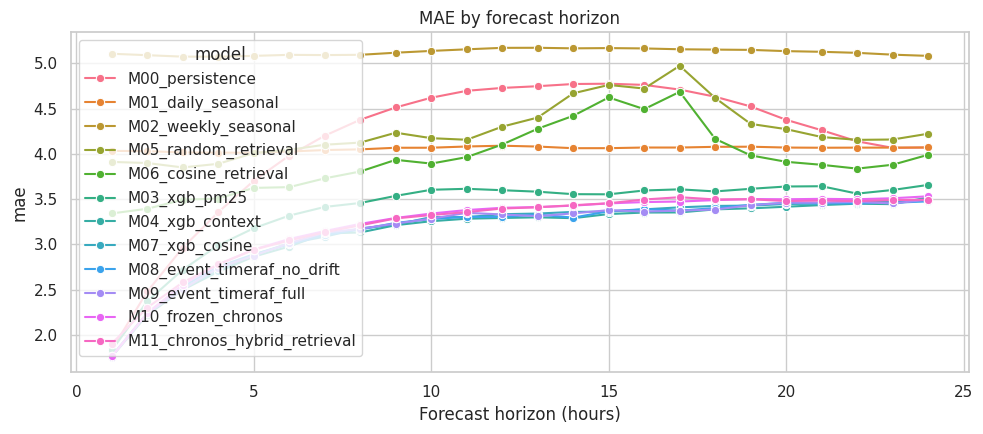

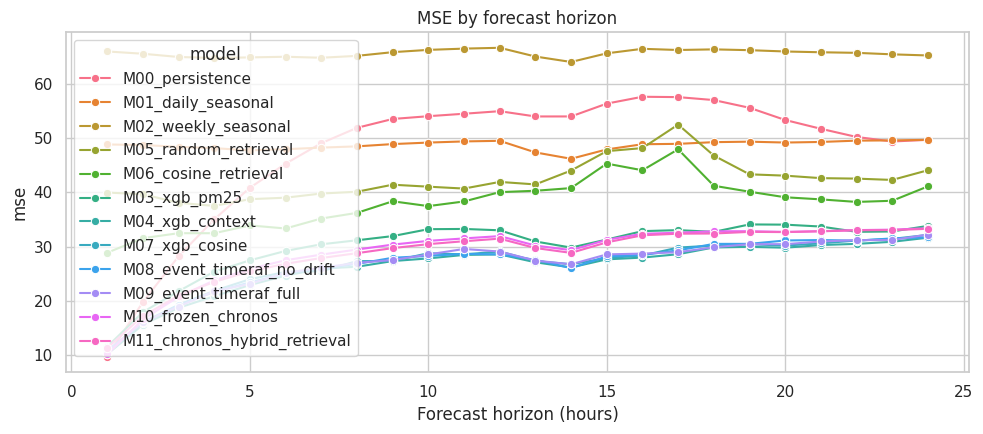

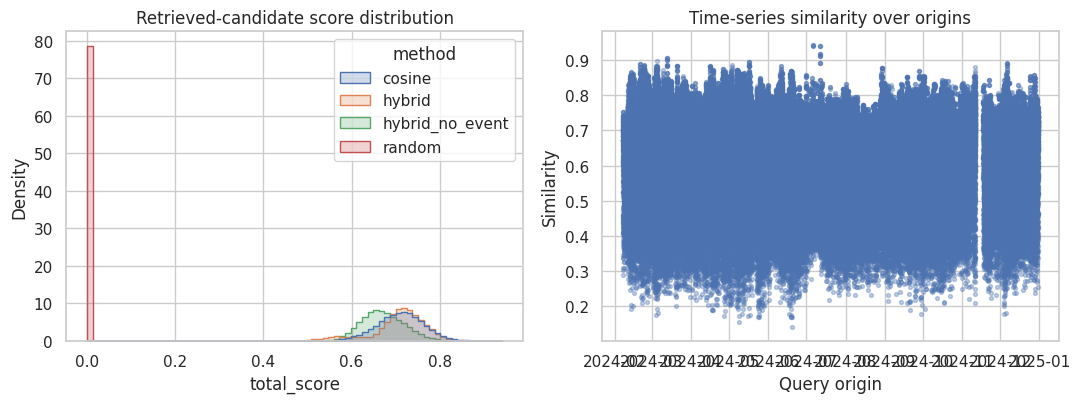

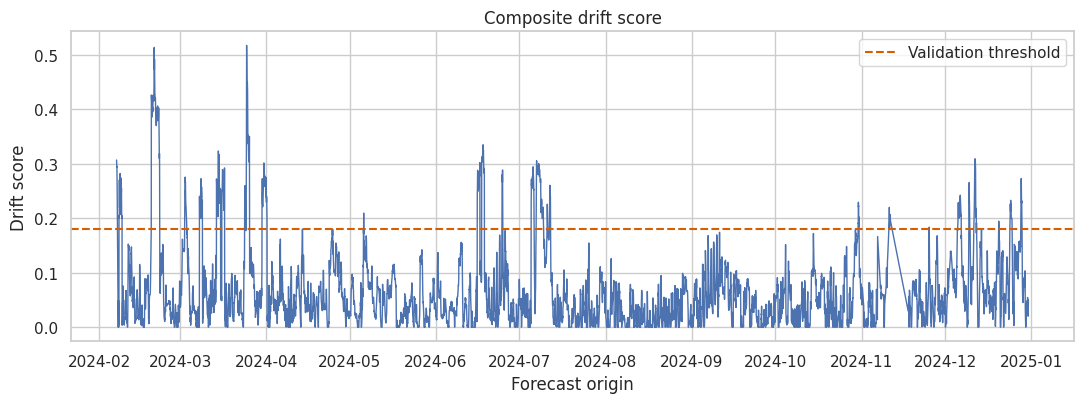

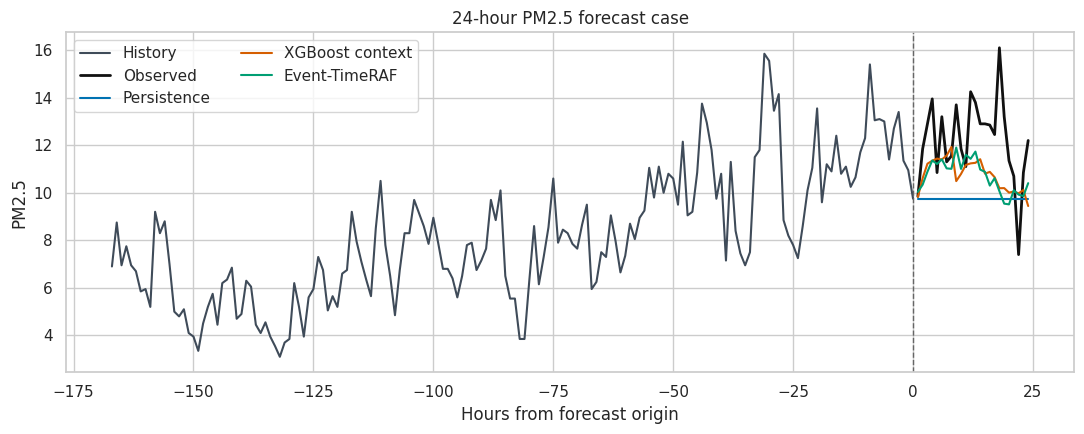

In [10]:
plot_horizon_metrics(
    metrics.loc[metrics['model'].str.startswith('M')],
    'mae', cfg.paths.outputs / 'figures' / 'mae_by_horizon.png'
)
mse_horizon_figure_path = cfg.paths.outputs / 'figures' / 'mse_by_horizon.png'
plot_horizon_metrics(metrics.loc[metrics['model'].str.startswith('M')], 'mse', mse_horizon_figure_path)
retrieval_figure_path = cfg.paths.outputs / 'figures' / 'retrieval_diagnostics.png'
drift_figure_path = cfg.paths.outputs / 'figures' / 'drift_scores.png'
plot_retrieval_diagnostics(evidence, retrieval_figure_path)
plot_drift_scores(drift_evidence.loc[drift_evidence['split'] == 'test'], drift_figure_path)
case_index = int(np.argsort(np.abs(test.y.mean(axis=1) - predictions['M09_event_timeraf_full'].mean(axis=1)))[len(test.y) // 2])
plot_forecast_case(
    test.x[case_index], test.y[case_index],
    {
        'Persistence': predictions['M00_persistence'][case_index],
        'XGBoost context': predictions['M04_xgb_context'][case_index],
        'Event-TimeRAF': predictions['M09_event_timeraf_full'][case_index],
    },
    cfg.paths.outputs / 'figures' / 'forecast_case.png',
)
forecast_figure_path = cfg.paths.outputs / 'figures' / 'forecast_case.png'
horizon_figure_path = cfg.paths.outputs / 'figures' / 'mae_by_horizon.png'
artifact_paths = [
    CONFIG_PATH, cfg.paths.outputs / 'audit' / 'data_audit.json',
    pm25_path, weather_path, event_kb_path, modeling_path,
    window_arrays_path, window_metadata_path, window_arrays_path.with_suffix('.json'),
    kb_arrays_path, kb_metadata_path, kb_arrays_path.with_suffix('.json'),
    retrieval_evidence_path, retrieval_review_path, drift_evidence_path,
    feature_effects_path, explanations_path, predictions_path,
    metrics_path, main_results_path, subset_counts_path, k_sensitivity_path,
    drift_period_path, event_period_path,
    retrieval_fusion_path, ablation_path, tsfm_gate_path,
    horizon_figure_path, mse_horizon_figure_path, forecast_figure_path,
    retrieval_figure_path, drift_figure_path,
    drift_detector_path, no_event_detector_path,
]
artifact_paths.extend(cfg.paths.outputs / 'models' / f'{name}.joblib' for name in models_to_save)
if RUN_TSF_MODEL:
    artifact_paths.extend([tsfm_predictions_path, fusion_scores_path])
manifest = write_run_manifest(
    cfg, artifact_paths, run_id=RUN_ID, config_path=CONFIG_PATH,
    started_at_utc=RUN_STARTED_AT.isoformat(),
    runtime_seconds=time.perf_counter() - RUN_STARTED_PERF,
    run_options={
        'force_download': FORCE_DOWNLOAD, 'require_events': REQUIRE_EVENTS,
        'strict_event_availability': REQUIRE_STRICT_EVENT_AVAILABILITY,
        'event_availability_mode': EVENT_AVAILABILITY_MODE,
        'storm_events_cache': str(storm_cache) if storm_cache is not None else None,
        'event_delivery_modes': audit['event_delivery_modes'],
        'run_tsf_model': RUN_TSF_MODEL, 'final_experiment': FINAL_EXPERIMENT,
        'retrieval_evidence_reviewed': RETRIEVAL_EVIDENCE_REVIEWED,
        'publication_title_allowed': bool(tsfm_gate_status['completed']),
    },
)
print(json.dumps(manifest, indent=2))
